
zn_R1s(r) =
+260.2199 * exp(-26.7103 r)
+179.9711 * r * exp(-22.7394 r)
+0.0778 * r * exp(-11.1579 r)
+740.4582 * r^2 * exp(-32.8592 r)
-0.0768 * r^2 * exp(-8.2265 r)
-0.0108 * r^2 * exp(-5.7011 r)
+0.0002 * r^2 * exp(-3.8393 r)
+3.6961 * r^3 * exp(-13.2036 r)
-0.0000 * r^3 * exp(-2.2676 r)
+0.0000 * r^3 * exp(-1.4378 r)
-0.0000 * r^3 * exp(-0.9462 r)

zn_R2s(r) =
-78.9207 * exp(-26.7103 r)
-538.1992 * r * exp(-22.7394 r)
+484.3071 * r * exp(-11.1579 r)
-55.6523 * r^2 * exp(-32.8592 r)
+63.2695 * r^2 * exp(-8.2265 r)
-1.4351 * r^2 * exp(-5.7011 r)
+0.1455 * r^2 * exp(-3.8393 r)
+1090.3821 * r^3 * exp(-13.2036 r)
-0.0016 * r^3 * exp(-2.2676 r)
+0.0001 * r^3 * exp(-1.4378 r)
-0.0000 * r^3 * exp(-0.9462 r)

zn_R3s(r) =
+29.2353 * exp(-26.7103 r)
+232.1573 * r * exp(-22.7394 r)
-212.7149 * r * exp(-11.1579 r)
-75.7180 * r^2 * exp(-32.8592 r)
-68.1939 * r^2 * exp(-8.2265 r)
+118.4779 * r^2 * exp(-5.7011 r)
+26.9787 * r^2 * exp(-3.8393 r)
-1292.8352 * r^3 * exp(-13.2036 r)
+0.0345 * r^3 * e

/tmp/ipykernel_11553/4158966515.py:129: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9999979205171271
Norm 2s = 1.0000007947787584
Norm 2p = 0.9999998916005081
Norm 3s = 1.000396876363134
Norm 3p = 0.9999996694276799
Norm 3d = 0.9999991031592418
Norm 4s = 0.9999993545766481
           Q   J_1s(2)       J_2s(2)       J_2p(6)       J_3s(2)  \
0       0.00  0.033605  1.273432e-01  6.499917e-02  3.553264e-01   
1       0.05  0.033604  1.273222e-01  6.499917e-02  3.548240e-01   
2       0.10  0.033603  1.272592e-01  6.499916e-02  3.533219e-01   
3       0.15  0.033601  1.271543e-01  6.499913e-02  3.508348e-01   
4       0.20  0.033598  1.270076e-01  6.499905e-02  3.473870e-01   
...      ...       ...           ...           ...           ...   
1996   99.80  0.000008  8.010846e-07  1.080768e-08  1.119241e-07   
1997   99.85  0.000008  7.987761e-07  1.076569e-08  1.116000e-07   
1998   99.90  0.000008  7.964752e-07  1.072388e-08  1.112770e-07   
1999   99.95  0.000008  7.941821e-07  1.068225e-08  1.109551e-07   
2000  100.00  0.000008  7.918966e-07  1.064081e-08

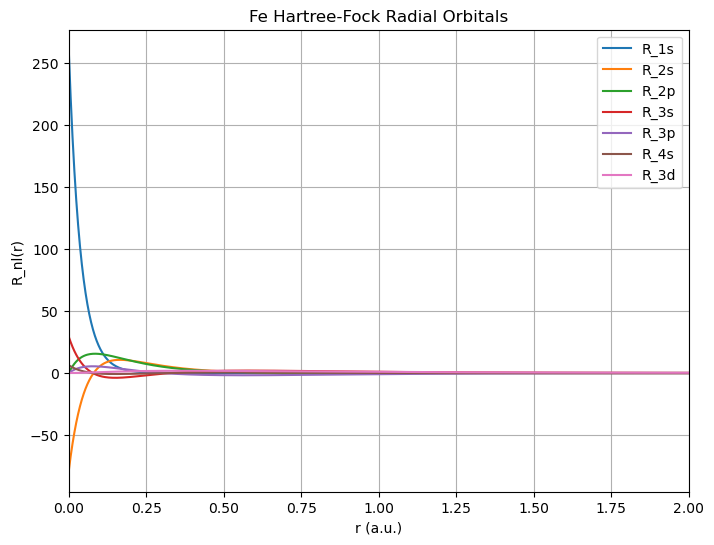

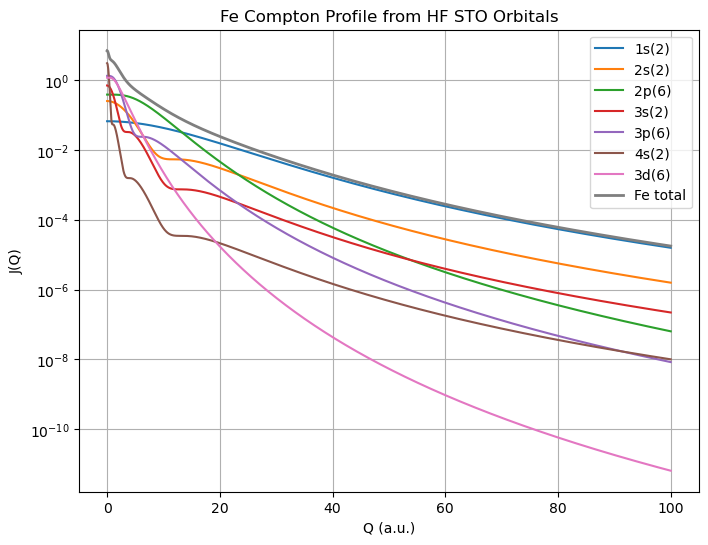

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Iron Hartree-Fock STO data
# Fe: 1s2 2s2 2p6 3s2 3p6 3d6 4s2
# Ground term: 5D
# Format: (n_j, Z_j, C_j)
# =====================================================

iron_1s = [
    (1, 26.7103,  0.942524),
    (2, 22.7394,  0.063210),
    (2, 11.1579,  0.000162),
    (3, 32.8592,  0.008635),
    (3,  8.2265, -0.000114),
    (3,  5.7011, -0.000058),
    (3,  3.8393,  0.000005),
    (4, 13.2036,  0.000297),
    (4,  2.2676, -0.000005),
    (4,  1.4378,  0.000003),
    (4,  0.9462, -0.000001),
]

iron_2s = [
    (1, 26.7103, -0.285853),
    (2, 22.7394, -0.189028),
    (2, 11.1579,  1.008545),
    (3, 32.8592, -0.000649),
    (3,  8.2265,  0.093973),
    (3,  5.7011, -0.007693),
    (3,  3.8393,  0.003112),
    (4, 13.2036,  0.087617),
    (4,  2.2676, -0.000360),
    (4,  1.4378,  0.000209),
    (4,  0.9462, -0.000070),
]

iron_3s = [
    (1, 26.7103,  0.105891),
    (2, 22.7394,  0.081539),
    (2, 11.1579, -0.442968),
    (3, 32.8592, -0.000883),
    (3,  8.2265, -0.101287),
    (3,  5.7011,  0.635102),
    (3,  3.8393,  0.577033),
    (4, 13.2036, -0.103885),
    (4,  2.2676,  0.007684),
    (4,  1.4378, -0.001785),
    (4,  0.9462,  0.000454),
]

iron_4s = [
    (1, 26.7103,  0.022650),
    (2, 22.7394,  0.017743),
    (2, 11.1579, -0.096526),
    (3, 32.8592,  0.000194),
    (3,  8.2265, -0.028327),
    (3,  5.7011,  0.171358),
    (3,  3.8393,  0.129599),
    (4, 13.2036, -0.024523),
    (4,  2.2676, -0.275750),
    (4,  1.4378, -0.539740),
    (4,  0.9462, -0.312861),
]

iron_2p = [
    (2, 42.2924,  0.000583),
    (2, 16.3351,  0.323715),
    (2,  8.7201,  0.434152),
    (2,  4.0978,  0.006165),
    (3, 13.2514,  0.288160),
    (3,  3.3690, -0.000634),
    (3,  2.1919,  0.000215),
]

iron_3p = [
    (2, 42.2924,  0.000148),
    (2, 16.3351,  0.068651),
    (2,  8.7201,  0.516640),
    (2,  4.0978, -0.821240),
    (3, 13.2514,  0.017006),
    (3,  3.3690, -0.407245),
    (3,  2.1919, -0.041825),
]

iron_3d = [
    (3, 12.7458,  0.017645),
    (3,  6.6281,  0.216184),
    (3,  4.0177,  0.414852),
    (3,  2.4057,  0.383883),
    (3,  1.4774,  0.129854),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Iron radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, iron_1s)
R2s = R_nl(r, iron_2s)
R3s = R_nl(r, iron_3s)
R4s = R_nl(r, iron_4s)
R2p = R_nl(r, iron_2p)
R3p = R_nl(r, iron_3p)
R3d = R_nl(r, iron_3d)

print_R_formula(iron_1s, "zn_R1s")
print_R_formula(iron_2s, "zn_R2s")
print_R_formula(iron_3s, "zn_R3s")
print_R_formula(iron_4s, "zn_R4s")
print_R_formula(iron_2p, "zn_R2p")
print_R_formula(iron_3p, "zn_R3p")
print_R_formula(iron_3d, "zn_R3d")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))


# Krypton has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 6*J_3d + 2*J_4s 

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s(2)": J_1s,
    "J_2s(2)": J_2s,
    "J_2p(6)": J_2p,
    "J_3s(2)": J_3s,
    "J_3p(6)": J_3p,
    "J_4s(1)": J_4s,
    "J_3d(10)":J_3d,
    "J_total_Fe": J_total
    })
print(table)
table.to_csv("Fe_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Fe Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 6*J_3d, label="3d(6)")
plt.plot(Q, J_total, label="Fe total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Fe Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()
